# ESTATÍSTICA DESCRITIVA, VISUALIZAÇÃO E ANÁLISE

## BIBLIOTECAS

In [18]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px

In [19]:
dados = pd.read_csv('data/processed/dados_airbnb_processados.csv', encoding='utf-8')
dados.shape

(19486, 13)

## ESTATÍSTICA DESCRITIVA COM PANDAS

### FUNÇÃO `.describe()`

In [20]:
## ESTATÍSTICAS BÁSICAS DE TODAS AS VARIÁVEIS NUMÉRICAS
dados.describe()

,id,latitude,longitude,accommodates,bathrooms,bedrooms,beds,price,review_scores_rating,review_scores_value
count,1.948600e+04,19486.000000,19486.000000,19486.000000,19486.000000,19486.000000,19486.000000,19486.000000,15597.000000,15592.000000
mean,7.838381e+17,-22.966014,-43.248259,3.965360,1.487350,1.508929,2.357744,684.673304,4.808450,4.725413
std,5.539296e+17,0.035805,0.099665,2.305749,0.969714,0.991313,2.161496,2917.856891,0.355563,0.403832
min,1.787800e+04,-23.072920,-43.696646,1.000000,0.000000,0.000000,0.000000,39.000000,1.000000,1.000000
25%,4.743713e+07,-22.984378,-43.302035,2.000000,1.000000,1.000000,1.000000,200.000000,4.760000,4.670000
50%,1.001868e+18,-22.971782,-43.193690,4.000000,1.000000,1.000000,2.000000,310.500000,4.920000,4.830000
75%,1.287317e+18,-22.952383,-43.184630,5.000000,2.000000,2.000000,3.000000,560.000000,5.000000,5.000000
max,1.450231e+18,-22.750510,-43.105520,16.000000,16.000000,27.000000,52.000000,225000.000000,5.000000,5.000000


- Estranhamente tem quartos, ou sem camas ou sem banheiros ou sem quartos

## GRÁFICOS E ANÁLISES


### Qual é o preço médio por tipo de hospedagem?
- calcular a média para comparação

#### CALCULANDO MÉDIA POR TIPO DE QUARTO


In [21]:
df_media = dados.groupby('room_type').agg(MEDIA = ('price','mean')).reset_index()
df_media

,room_type,MEDIA
0,Entire home/apt,743.743368
1,Hotel room,413.500000
2,Private room,454.428532
3,Shared room,244.569149


#### GRÁFICO DE BARRAS


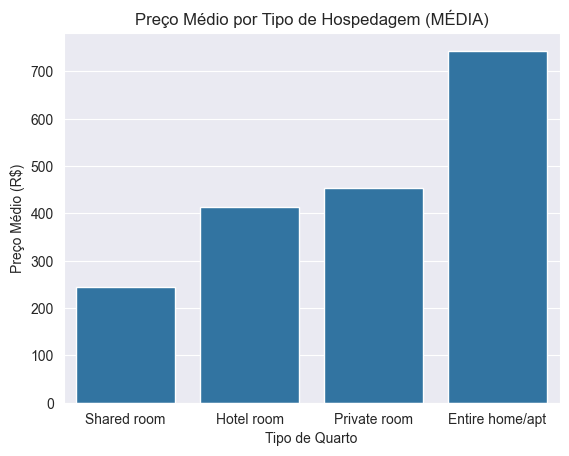

In [22]:
sns.barplot(x = 'room_type', y = 'MEDIA',
            data = df_media.sort_values('MEDIA') ## ORDENANDO AS BARRAS PELO VALOR
            )
plt.title("Preço Médio por Tipo de Hospedagem (MÉDIA)")
plt.xlabel("Tipo de Quarto")
plt.ylabel("Preço Médio (R$)")
plt.show()

#### ANÁLISES
- Observa-se que a diferença da média da diária do `entire home` é quase o dobro  da segunda maior média
- já as demais hospedagens tem um valor médio próximo
- e, hospedagem do tipo `shared` tem a menor média e quase a metade do valor da `private`
- Mas, será que existe algum valor extremo que está puxando a média do `entire`?
  - podemos confirmar isso pela **mediana** ou pela a `distribuição` dos valores!

#### CALCULANDO MEDIANA POR TIPO DE QUARTO


In [23]:
df_mediana = dados.groupby('room_type').agg(MEDIANA = ('price','median')).reset_index()
df_mediana

,room_type,MEDIANA
0,Entire home/apt,346.0
1,Hotel room,402.5
2,Private room,205.0
3,Shared room,91.0


#### GRÁFICO DE BARRAS


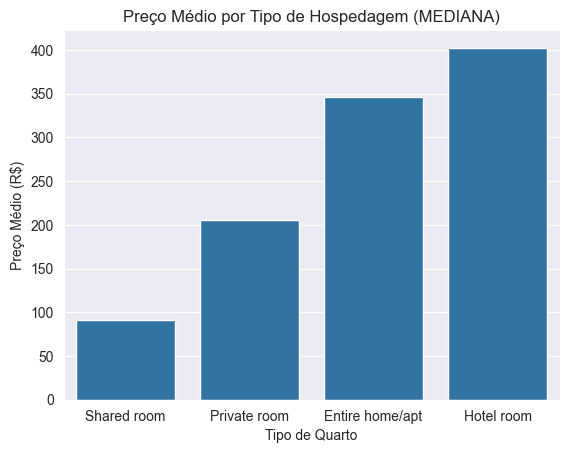

In [24]:
sns.barplot(x = 'room_type', y = 'MEDIANA',
            #color = 'grey',
            data = df_mediana.sort_values('MEDIANA')
            )

plt.title("Preço Médio por Tipo de Hospedagem (MEDIANA)")
plt.xlabel("Tipo de Quarto")
plt.ylabel("Preço Médio (R$)")
plt.show()

##### ANÁLISES
- O valor da mediana reflete preços mais consistentes e elevados para hotel room. Entire home varia de "muito barato" ao "luxo", o que infla a média, mas mantém o preço típico (mediana) abaixo dos hotéis.
- `shared` parece ter o menor preço médio pela metade da comparação pela média, enquanto o `private` room também em comparação com si próprio


---

### Qual a distribuição das diárias por tipo de hospedagem?
- Pode-se utilizar o Boxplot, porque vai mostrar tanto a distribuição quanto outras estatísticas

#### GERANDO BOXPLOT


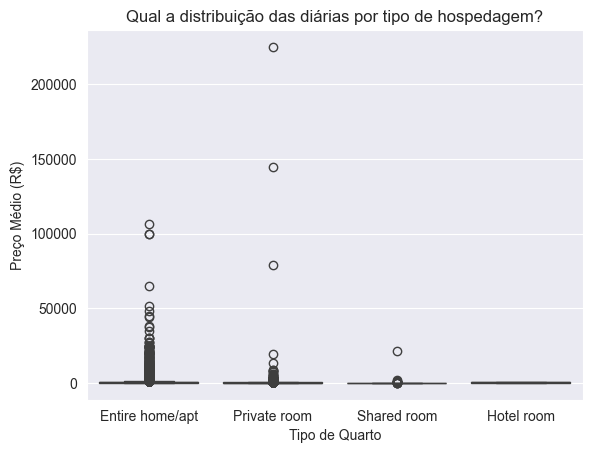

In [25]:
# para o boxplot não é necessário agrupar os dados,
# é possível fazer na base original
sns.boxplot(x = 'room_type', y = 'price', data = dados)
plt.title("Qual a distribuição das diárias por tipo de hospedagem?")
plt.xlabel("Tipo de Quarto")
plt.ylabel("Preço Médio (R$)")
plt.show()

##### ANÁLISES
-  Private room: Como um quarto privativo (geralmente um quarto dentro de uma casa habitada) pode custar 225 mil a diária?

| Tipo de Quarto | Comportamento de Preço |
| :---: | :--- |
| Shared room | O mais barato e com menor variação (baixo risco/baixo custo). |
| Private room | Barato, mas com muitos outliers (pessoas tentando cobrar caro por quartos simples). |
| Hotel room	| Faixa de preço mais "apertada" e alta. Você sabe o que esperar pagar. |
| Entire home/apt	| Maior volatilidade. É o grupo que vai do econômico ao luxo total. |

#### GERANDO BOXPLOT SEM OUTLIER


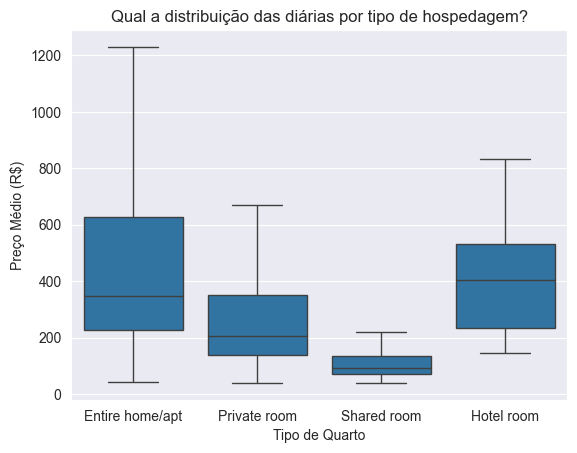

In [26]:
sns.boxplot(x = 'room_type', y = 'price',
            showfliers = False, ## OCULTA OS VALORES EXTREMOS
            data = dados)
plt.title("Qual a distribuição das diárias por tipo de hospedagem?")
plt.xlabel("Tipo de Quarto")
plt.ylabel("Preço Médio (R$)")
plt.show()

##### ANÁLISES
- Diferente do que a média sugeria antes, o Hotel Room tem a mediana mais alta de todos (o traço horizontal dentro da caixa azul).
- `Hotel Room` em um cenário normal, é mais caro reservar um quarto de hotel do que um apartamento inteiro. Os hotéis têm um "piso" de preço mais alto (a base da caixa começa mais acima que as outras).
- `Entire Home/Apt` a caixa azul desse grupo é a mais "comprida" (maior IQR - Intervalo Interquartil) e tem o "bigode" superior mais longo, chegando perto de 1200.
- `Shared Room` a variação é mínima, o que indica um mercado muito padronizado e focado puramente em baixo custo para quem quer economizar.



---

## Qual bairro tem a melhor relação preço/avaliação?
1. Coluna de Relação: **['review_scores_value']¹ ** e **['neighbourhood_cleansed']²**
   - 1: Coluna de percepção de valor real do hóspede
   - 2: Coluna de Bairros
2. Agrupar calculando a nota média e contando quantos imóveis tem no bairro
3. Filtrar apenas bairros mais relevantes (com mais de 20 avaliações)
3. Pegar os 10 melhores a partir dessa lista
4. Criar o gráfico

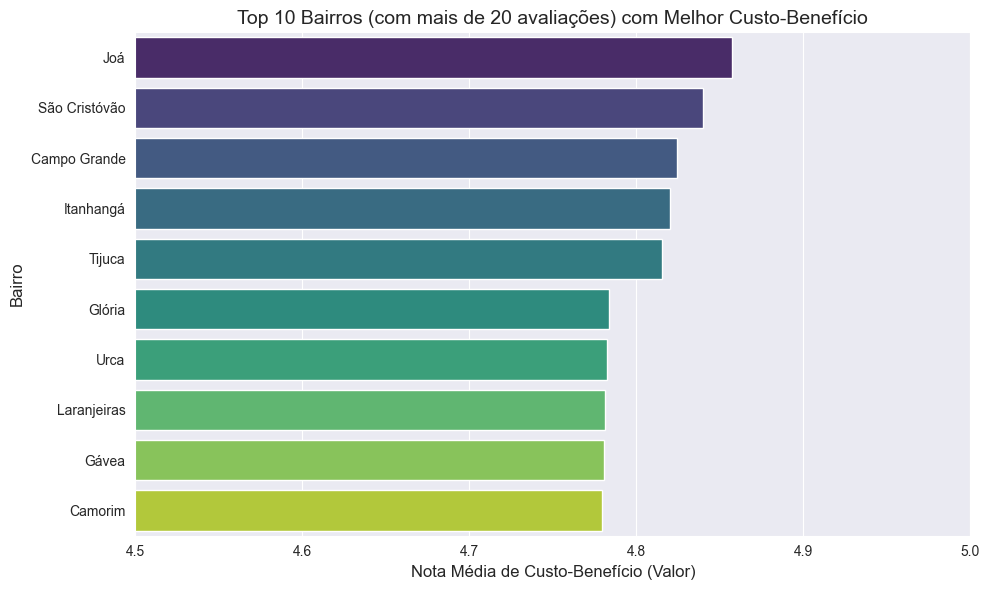

In [27]:
agrupado = dados.groupby('neighbourhood_cleansed').agg(
    nota_media=('review_scores_value', 'mean'),
    quantidade_imoveis=('review_scores_value', 'count')
).reset_index()

bairros_relevantes = agrupado[agrupado['quantidade_imoveis'] >= 20]

# 3. Pegar os 10 melhores a partir dessa lista filtrada
top_10_bairros = bairros_relevantes.sort_values(by='nota_media', ascending=False).head(10)

# Gráfico
plt.figure(figsize=(10, 6))
sns.barplot(
    x='nota_media',
    y='neighbourhood_cleansed',
    data=top_10_bairros,
    palette='viridis',
    hue='neighbourhood_cleansed',
    legend=False
)

plt.title('Top 10 Bairros (com mais de 20 avaliações) com Melhor Custo-Benefício', fontsize=14)
plt.xlabel('Nota Média de Custo-Benefício (Valor)', fontsize=12)
plt.ylabel('Bairro', fontsize=12)

plt.xlim(4.5, 5.0)

plt.tight_layout()
plt.show()

### VISUALIZAÇÃO GEOESPACIAL: MAPA DE CALOR (Custo-Benefício)

In [31]:
dados_mapa = dados.dropna(subset=['review_scores_value'])

# Cria o mapa interativo
grafico_mapa = px.density_mapbox(
    dados_mapa,
    lon="longitude",
    lat="latitude",
    z="review_scores_value",
    radius=10,
    zoom=10,
    center={"lat": -22.93, "lon": -43.20}, # Centro do Rio de Janeiro
    mapbox_style="carto-positron",
    title="Mapa de Calor: Onde estão as melhores avaliações de Custo-Benefício?",
    color_continuous_scale=px.colors.sequential.YlGnBu,
    range_color=[4.5, 5]
)

grafico_mapa.show()

## Preparação para ML: Cálculo de Intervalo Interquartil (IQR)
- Para não gerar agrupamentos ruins e alimentar o algoritmo com outliers, como o preço de 225 mil.
- No notebook 3 iremos utilizar o algoritmo não supervisionado KMeans para segmentar os imóveis. Por ele ser  é sensível a valores extremos
- IQR é uma forma de lidar com a assimetria de outliers
 - Por ser um modelo puramente matemático baseado no cálculo de distâncias euclidianas, o K-Means é extremamente sensível a valores extremos. Se mantivermos diárias de R$ 14.000 na base, o algoritmo criará agrupamentos distorcidos e pouco representativos da realidade do mercado.
- Ele nos permite definir uma "cerca" matemática (Limite Superior) para isolar e remover essas anomalias de preço antes de exportarmos os dados para a clusterização
- O cálculo é o seguinte, para eliminar extremos:
  - **IQR = Q3 - Q1**
  - **Limite Superior = Q3 + 1.5 * IQR**

In [29]:
Q1 = dados['price'].quantile(0.25)
Q3 = dados['price'].quantile(0.75)

IQR = Q3 - Q1
limite_superior = Q3 + 1.5 * IQR

print(f"O limite superior matemático para o preço comum é: R$ {limite_superior:.2f}")

# Filtra a base mantendo apenas imóveis com preço menor que o limite
dados_sem_outliers = dados[dados['price'] <= limite_superior]

print(f"Tamanho original: {dados.shape[0]} linhas")
print(f"Tamanho após filtro: {dados_sem_outliers.shape[0]} linhas")

O limite superior matemático para o preço comum é: R$ 1100.00
Tamanho original: 19486 linhas
Tamanho após filtro: 17575 linhas


In [30]:
# Salva a base final pronta para a K-Means no notebook 3
dados_sem_outliers.to_csv('data/processed/dados_ml.csv', encoding='utf-8', index=False)